# Geometry tests — NN bond patterns

For each lattice geometry we:
1. Build a nearest-neighbour Hamiltonian MPO via `build_hamiltonian`.
2. Extract the full matrix with `get_matrix` (feasible only for small `L`).
3. Plot the sites on a square grid indexed by **row-major** order
   (`n = ix + iy * Nx`, so column `ix` runs fastest) and draw a bond
   between every pair `(i, j)` with `|H[i,j]| > threshold`.

In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

## Parameters and Hamiltonians

`Lx` and `Ly` are the **exponents**: the physical grid is `2^Lx × 2^Ly` sites.

In [9]:
Lx, Ly = 3, 3          # 4 × 4 = 16 sites
L  = Lx + Ly
Nx = 2^Lx
Ny = 2^Ly
N  = Nx * Ny

println("Grid: $(Nx) × $(Ny) = $(N) sites,  L = $(L) qubits")

Grid: 8 × 8 = 64 sites,  L = 6 qubits


In [10]:
H_sq  = TensorBinding.build_hamiltonian("square_2d",     Lx, Ly; mparams="t=1.0")
H_tri = TensorBinding.build_hamiltonian("triangular_2d", Lx, Ly; mparams="t=1.0")
H_hex = TensorBinding.build_hamiltonian("hex_2d",        Lx, Ly; mparams="t=1.0")

MPO
[1] ((dim=2|id=62|"Qubit,Site,n=1")', (dim=2|id=62|"Qubit,Site,n=1"), (dim=4|id=168|"Link,l=1"))
[2] ((dim=2|id=225|"Qubit,Site,n=2")', (dim=2|id=225|"Qubit,Site,n=2"), (dim=3|id=595|"Link,l=2"), (dim=4|id=168|"Link,l=1"))
[3] ((dim=2|id=361|"Qubit,Site,n=3")', (dim=2|id=361|"Qubit,Site,n=3"), (dim=3|id=576|"Link,l=3"), (dim=3|id=595|"Link,l=2"))
[4] ((dim=2|id=270|"Qubit,Site,n=4")', (dim=2|id=270|"Qubit,Site,n=4"), (dim=5|id=143|"Link,l=4"), (dim=3|id=576|"Link,l=3"))
[5] ((dim=2|id=686|"Qubit,Site,n=5")', (dim=2|id=686|"Qubit,Site,n=5"), (dim=3|id=506|"Link,l=5"), (dim=5|id=143|"Link,l=4"))
[6] ((dim=2|id=776|"Qubit,Site,n=6")', (dim=2|id=776|"Qubit,Site,n=6"), (dim=3|id=506|"Link,l=5"))


## Extract full matrices

`build_hamiltonian` creates site indices internally, so we pull them from the MPO.

In [11]:
sites_sq  = getindex.(siteinds(H_sq),  2)
sites_tri = getindex.(siteinds(H_tri), 2)
sites_hex = getindex.(siteinds(H_hex), 2)

M_sq  = TensorBinding.get_matrix(H_sq,  L, sites_sq)
M_tri = TensorBinding.get_matrix(H_tri, L, sites_tri)
M_hex = TensorBinding.get_matrix(H_hex, L, sites_hex)

println("Max off-diagonal (sq):  ", maximum(abs, M_sq  - Diagonal(diag(M_sq))))
println("Max off-diagonal (tri): ", maximum(abs, M_tri - Diagonal(diag(M_tri))))
println("Max off-diagonal (hex): ", maximum(abs, M_hex - Diagonal(diag(M_hex))))

Max off-diagonal (sq):  1.0000000000000042
Max off-diagonal (tri): 1.0000000000000022
Max off-diagonal (hex): 1.0000000000000018


## Plotting helper

Sites sit on an integer grid at `(ix, iy)` with `ix = n % Nx`, `iy = n ÷ Nx`.
A grey line is drawn for every pair `(i, j)` where `|H[i,j]| > threshold`.

In [5]:
function plot_bonds(M, Lx, Ly; title="", threshold=0.3)
    Nx = 2^Lx
    N  = 2^(Lx + Ly)

    # site coordinates (0-indexed, row-major)
    xs = Float64[n % Nx for n in 0:N-1]
    ys = Float64[n ÷ Nx for n in 0:N-1]

    plt = plot(; title=title, aspect_ratio=:equal, legend=false,
                 axis=false, grid=false,
                 xlims=(-0.7, Nx - 0.3), ylims=(-0.7, N÷Nx - 0.3))

    # bonds first so sites appear on top
    for i in 1:N, j in i+1:N
        if abs(M[i, j]) > threshold
            plot!(plt, [xs[i], xs[j]], [ys[i], ys[j]];
                  color=:gray, linewidth=2, alpha=0.8)
        end
    end

    # sites
    scatter!(plt, xs, ys;
             markersize=14, color=:steelblue,
             markerstrokecolor=:white, markerstrokewidth=1.5)

    # site labels (0-based linear index)
    for n in 0:N-1
        annotate!(plt, xs[n+1], ys[n+1],
                  text(string(n), 7, :white, :center))
    end

    return plt
end

plot_bonds (generic function with 1 method)

## Square lattice

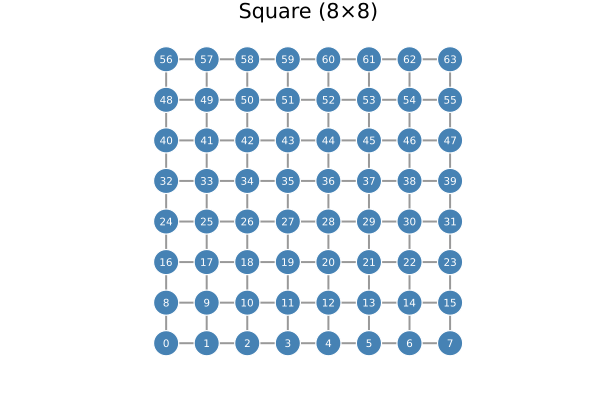

In [12]:
plot_bonds(real.(M_sq), Lx, Ly; title="Square ($(Nx)×$(Ny))")

## Triangular lattice

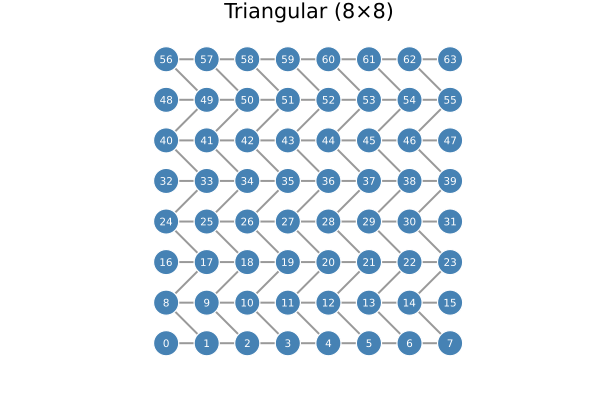

In [13]:
plot_bonds(real.(M_tri), Lx, Ly; title="Triangular ($(Nx)×$(Ny))")

## Honeycomb lattice

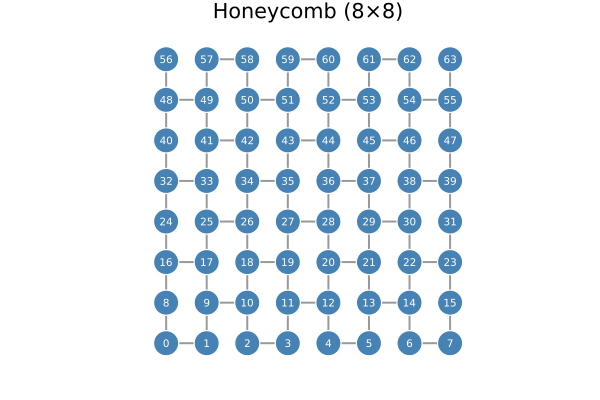

In [14]:
plot_bonds(real.(M_hex), Lx, Ly; title="Honeycomb ($(Nx)×$(Ny))")

## All three side by side

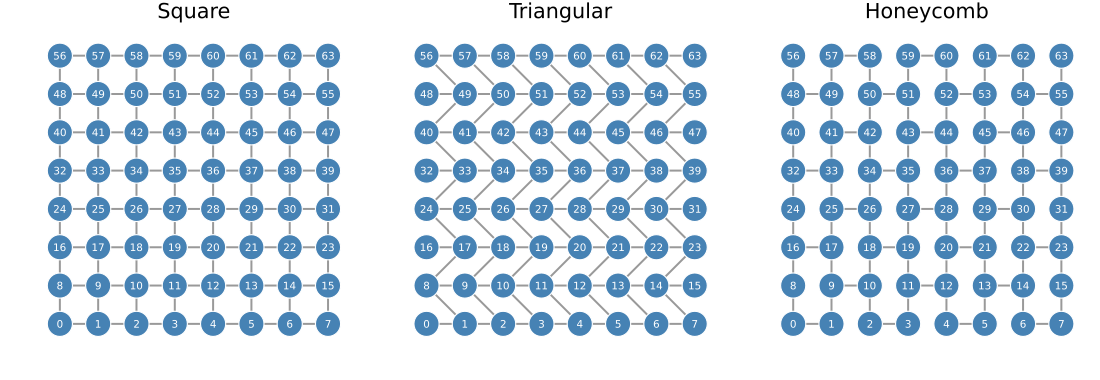

In [15]:
p1 = plot_bonds(real.(M_sq),  Lx, Ly; title="Square")
p2 = plot_bonds(real.(M_tri), Lx, Ly; title="Triangular")
p3 = plot_bonds(real.(M_hex), Lx, Ly; title="Honeycomb")
plot(p1, p2, p3; layout=(1, 3), size=(1100, 380))